In [1]:
import os
import GEOparse
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

# Import Data

In [2]:

def load_expression_matrix(filepath):
    data = GEOparse.get_GEO(filepath=filepath)
    full_df = data.table

    gsm_cols = [col for col in full_df.columns if col.startswith('GSM')]

    expr_df = (
        full_df
        .loc[:, ['IDENTIFIER'] + gsm_cols]
        .dropna(subset=['IDENTIFIER'])
        .set_index('IDENTIFIER')
    )

    expr_df = expr_df.apply(pd.to_numeric, errors='coerce')

    expr_df_collapsed = expr_df.groupby(expr_df.index).mean()

    return expr_df_collapsed.T
    

In [3]:

expr = load_expression_matrix("data/GDS4414_full.soft")
sample = expr.iloc[2]
sample.head()

06-Mar-2026 15:46:18 INFO GEOparse - Parsing data/GDS4414_full.soft: 
06-Mar-2026 15:46:18 DEBUG GEOparse - DATABASE: Geo
06-Mar-2026 15:46:18 DEBUG GEOparse - DATASET: GDS4414
06-Mar-2026 15:46:18 DEBUG GEOparse - SUBSET: GDS4414_1
06-Mar-2026 15:46:18 DEBUG GEOparse - SUBSET: GDS4414_2
06-Mar-2026 15:46:18 DEBUG GEOparse - SUBSET: GDS4414_3
06-Mar-2026 15:46:18 DEBUG GEOparse - SUBSET: GDS4414_4
06-Mar-2026 15:46:18 DEBUG GEOparse - SUBSET: GDS4414_5
06-Mar-2026 15:46:18 DEBUG GEOparse - SUBSET: GDS4414_6
06-Mar-2026 15:46:18 DEBUG GEOparse - ANNOTATION: 
06-Mar-2026 15:46:18 ERROR GEOparse - Cannot recognize type Annotation
06-Mar-2026 15:46:18 DEBUG GEOparse - DATASET: GDS4414
/opt/anaconda3/lib/python3.13/site-packages/GEOparse/GEOparse.py:401: DtypeWarning: Columns (28) have mixed types. Specify dtype option on import or set low_memory=False.
  return read_csv(StringIO(data), index_col=None, sep="\t")


IDENTIFIER
--Control        9.073441
0610005C13Rik    3.848540
0610006L08Rik    3.993080
0610007P14Rik    9.201110
0610009B22Rik    9.678720
Name: GSM636862, dtype: float64

# Sample Descriptive Statistics

In [4]:
class SampleProfile:
    def __init__(self, data):
        self.original = data
        self.array = self._to_numpy(data)
        self.stats = self._compute_stats()

    def _to_numpy(self, data):
        if isinstance(data, pd.Series):
            return data.to_numpy()
        elif isinstance(data, pd.DataFrame):
            if data.shape[0] == 1:
                return data.iloc[0].to_numpy()
            else:
                raise ValueError("DataFrame must contain exactly one row.")
        elif isinstance(data, np.ndarray):
            return data
        else:
            raise TypeError("Unsupported data type.")

    def _compute_stats(self):
        return {
            "mean": np.mean(self.array),
            "median": np.median(self.array),
            "std": np.std(self.array),
            "min": np.min(self.array),
            "max": np.max(self.array),
            "range": np.ptp(self.array),
            "variance": np.var(self.array)
        }


In [5]:
profile = SampleProfile(sample)
print(profile.stats["max"])
print(profile.stats["variance"])

14.171475000000001
4.947071670159146


# Adding in a Mutation

In [6]:
def mutation_generator(initial_row):
    """
    Creates an array the same size as input containing zeros except for one random position.

    Args:
        initial_row (binary list or np.array): one row containing expression data that has been MaxMin scaled, specified by user
        
    Returns:
        mutation (np.array): array of all zeros except for one random postion
    """
    # Initialize random generator 
    rng = np.random.default_rng()
    
    # Create an array of zeros that is the same shape as initial sample
    mutation_array = np.zeros_like(initial_row)
    
    # Define a random index to insert before
    random_index = rng.integers(0, len(initial_row))
    mutation_value = rng.uniform(0, 1)
    mutation_array[random_index] = mutation_value

    return mutation_array
                                      

In [ ]:
initial_row = sample[0: 10]
mutation_generator(initial_row)

In [7]:
def genomic_sample_row_mutation(
    initial_row, 
    num_rows, 
    stat, 
    decay_scale, 
    mutation_frequency,
    mutation_intensity, 
    filename,
    cmap="gray",
    plot=False, 
    save=False,
    results_dir="results"
):
    """
    Generate a 2D matrix by iteratively applying decay and periodic mutations to an initial genomic signal vector.

    Args:
        initial_row : array-like 1D array representing the starting genomic signal.
        num_rows (int) : Total number of rows (iterations) to generate.
        stat (float) : Descriptive statistic (e.g., median or mean) used to compute decay rate.
        decay_scale (float) : Scaling factor controlling the strength of decay per iteration.
        mutation_frequency (int) : Interval (in rows) at which mutations are introduced.
            - For example, 5 means every 5th row will include a mutation.
        mutation_intensity (float) : Scaling factor controlling the magnitude of mutations generated by `mutation_generator`.
        filename (str or None optional) : Name of the file used when saving the plot. 
            - If None, a default filename will be used.
        cmap (str, optional) : Matplotlib colormap used for visualization (default is "gray").
        plot (bool, optional) : If True, displays the generated matrix as an image.
        save (bool, optional) : If True, saves the generated plot to disk.
        results_dir (str, optional) : Directory where plots are saved (default is "results").

    Returns:
        np.array: resulting matrix and plot in a unique color pattern
    """

    current_row = np.array(initial_row)
    rows = [current_row]
    decay_rate = stat * decay_scale 

    for row in range(1, num_rows):

        # gradual decay each row based on deacy scale   
        next_row = current_row - (decay_rate * np.sqrt(current_row))

        # introduce mutation
        if row % mutation_frequency == 0:
            mutation = mutation_generator(current_row) * mutation_intensity
            next_row = next_row + mutation

        next_row = np.clip(next_row, 0, 1)
        rows.append(next_row)
        current_row = next_row

    matrix = np.vstack(rows)

    if plot:
        fig, ax = plt.subplots(figsize=(6,6))
        ax.imshow(matrix, cmap=cmap, interpolation='nearest')
        ax.set_xticks([])
        ax.set_yticks([])

        if save:
            os.makedirs(results_dir, exist_ok=True)
            if filename is None:
                filename = "genomic_visualization.png"
            filepath = os.path.join(results_dir, filename)
            fig.savefig(filepath, dpi=300, bbox_inches="tight")

    return matrix


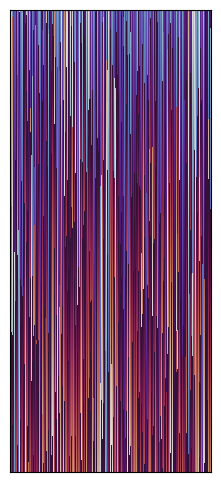

In [8]:
initial_row = sample[0: 2700].to_numpy()
row_to_scale = initial_row.reshape(-1, 1)
scaler = MinMaxScaler()
scaled_row = scaler.fit_transform(row_to_scale)
normalized_row = scaled_row.flatten()
stat = profile.stats["variance"] 

single_row_mutation = genomic_sample_row_mutation(
    normalized_row, 
    6200, 
    stat,
    decay_scale=0.00002,
    mutation_frequency = 1,
    mutation_intensity = profile.stats["std"],
    filename="single_row_mutation_median_decay_v2.png",
    cmap="twilight_shifted",
    plot=True,
    save=False,
    results_dir="results"
)


In [9]:
def genomic_one_uniform_neighbor(
    initial_row, 
    num_rows, 
    sample_max, 
    decay, 
    filename,
    cmap="gray",
    plot=False, 
    save=False,
    results_dir="results"
):
    """
    1D cellular automaton creating a matrix where each subsequent row is derived from the previous row applying 
    the exactly 1 neighbor is 1 rule. 

    Args:
        initial_row (binary list or np.array): first row of the matrix, specified by user
        num_rows (int): number of itterations to run (rows to derive and add to matrix)
        sample_max (float64): maximum value in intial row
        decay (int): for scaling color saturation
        filename (str or None optional) : Name of the file used when saving the plot. 
            - If None, a default filename will be used.
        cmap (str): Color map name (default = "twilight_shifted")
        plot (bool, optional) : If True, displays the generated matrix as an image.
        save (bool, optional) : If True, saves the generated plot to disk.
        results_dir (str, optional) : Directory where plots are saved (default is "results").

    Returns:
        np.array: resulting plot of generated pattern of unique shaded pyraminds 
    """

    initial_row = np.array(initial_row)
    matrix = [initial_row]

    for row in range(num_rows):
        current_row = matrix[-1]
        next_row = []
        for square in range(len(current_row)):
            
            left = current_row[square-1] if square > 0 else 0
            right = current_row[square+1] if square < len(current_row)-1 else 0
            # apply XOR rule, exactly one neighbor is 1
            if (left == sample_max) ^ (right == sample_max):
                next_square = sample_max

            else:

                count = 1
                pointer = 2 

                while True:
                    
                    left_index = square - pointer
                    right_index = square + pointer

                    if left_index < 0 or right_index >= len(current_row):
                        break

                    left = current_row[left_index]
                    right = current_row[right_index]

                    if (left != 1 and right != 1):
                        count += 1
                        pointer += 1
                                                   
                    else:
                        break  
                        
                next_square = (current_row[square]-(sample_max))

            next_row.append(next_square)
        #next_row = np.clip(next_row, 0, 1)
        matrix.append(next_row)

    matrix = np.array(matrix)

    if plot:
        fig, ax = plt.subplots(figsize=(6,6))
        ax.imshow(matrix, cmap=cmap, interpolation='nearest')
        ax.set_xticks([])
        ax.set_yticks([])

        if save:
            os.makedirs(results_dir, exist_ok=True)
            if filename is None:
                filename = "genomic_visualization.png"
            filepath = os.path.join(results_dir, filename)
            fig.savefig(filepath, dpi=300, bbox_inches="tight")

    return matrix
    

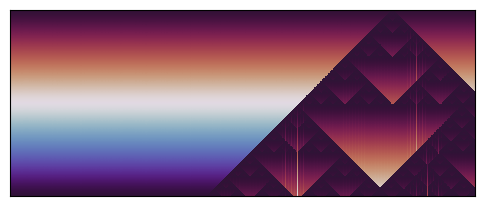

In [10]:
initial_row = sample[0: 2500].to_numpy()
row_to_scale = initial_row.reshape(-1, 1)
scaled_row = [MinMaxScaler().fit_transform(row_to_scale)][0]
normalized_row = scaled_row.flatten()
sample_max = np.max(normalized_row)
size = len(normalized_row) 
decay = size/2

one_uniform_neighbor_v3 = genomic_one_uniform_neighbor(
    normalized_row, 
    num_rows=1000, 
    sample_max=sample_max, 
    decay=decay, 
    filename="genomic_one_uniform_neighbor_v3.png",
    cmap="twilight_shifted",
    plot=True,
    save=False,
    results_dir="results"
)

In [ ]:
def one_uniform_neighbor_genomic_background_decay(
    initial_row, 
    num_rows, 
    sample_max, 
    sample_mean,
    decay,
    mutation_frequency,
    filename,
    cmap="gray",
    plot=False, 
    save=False,
    results_dir="results"
):
    """
    1D cellular automaton creating a matrix where each subsequent row is derived from the previous row applying 
    the exactly 1 neighbor is 1 rule. 

    Args:
        initial_row (binary list or np.array): first row of the matrix, specified by user
        num_rows (int): number of itterations to run (rows to derive and add to matrix)
        sample_max (float64): maximum value in intial row
        decay (int): for scaling color saturation
        filename (str or None optional) : Name of the file used when saving the plot. 
            - If None, a default filename will be used.
        cmap (str): Color map name (default = "twilight_shifted")
        plot (bool, optional) : If True, displays the generated matrix as an image.
        save (bool, optional) : If True, saves the generated plot to disk.
        results_dir (str, optional) : Directory where plots are saved (default is "results").

    Returns:
        np.array: resulting plot of generated pattern of unique shaded pyraminds 
    """

    initial_row = np.array(initial_row)
    matrix = [initial_row]

    for row in range(num_rows):
        current_row = matrix[-1]
        next_row = []
        for square in range(len(current_row)):
            
            left = current_row[square-1] if square > 0 else 0
            right = current_row[square+1] if square < len(current_row)-1 else 0
            center = current_row[square]
            # apply XOR rule, exactly one neighbor is 1
            if (left == sample_max) ^ (right == sample_max):
                next_square = sample_max
                
            #elif center <= decay_rate * 5:
                #next_square = center + np.sqrt(sample_mean)
                #next_square = center + sample_mean
                
            else:
                next_square = center - (decay_rate * center)
                #next_square = initial_row[square]

            next_square = np.clip(next_square, 0, 1)
            next_row.append(next_square)

        # introduce mutation
        if row % mutation_frequency == 0:
            mutation = mutation_generator(current_row) * 0.95
            next_row = next_row + mutation

        next_row = np.clip(next_row, 0, 1)
            
        matrix.append(next_row)

    matrix = np.array(matrix)

    if plot:
        fig, ax = plt.subplots(figsize=(12,6))
        ax.imshow(matrix, cmap=cmap, interpolation='nearest')
        ax.set_xticks([])
        ax.set_yticks([])

        if save:
            os.makedirs(results_dir, exist_ok=True)
            if filename is None:
                filename = "genomic_visualization.png"
            filepath = os.path.join(results_dir, filename)
            fig.savefig(filepath, dpi=300, bbox_inches="tight")

    return matrix

In [ ]:
initial_row = sample[0: 1450].to_numpy()
row_to_scale = initial_row.reshape(-1, 1)
scaler = MinMaxScaler()
scaled_row = scaler.fit_transform(row_to_scale)
normalized_row = scaled_row.flatten()
sample_max = np.max(normalized_row) # use to initiat wolfram rule
sample_mean = np.mean(normalized_row)
size = len(normalized_row) 
decay_rate = 0.01
mutation_frequency = 2

one_uniform_neighbor_genomic_background_v2 = one_uniform_neighbor_genomic_background_decay(
    normalized_row, 
    num_rows=350, 
    sample_max=sample_max,
    sample_mean=sample_mean,
    decay=decay_rate, 
    mutation_frequency=mutation_frequency,
    filename="one_uniform_neighbor_genomic_background_v2.png",
    cmap="bone_r",
    plot=True,
    save=False,
    results_dir="results"
)

In [ ]:
def rule_57_genomic_background_decay(
    initial_row, 
    num_rows, 
    sample_max, 
    sample_mean,
    decay_rate,
    filename,
    cmap="gray",
    plot=False, 
    save=False,
    results_dir="results"
):
    """
    1D cellular automaton creating a matrix where each subsequent row is derived from the previous row applying 
    Wolfram's rule 57. 

    Args:
        initial_row (binary list or np.array): first row of the matrix, specified by user
        num_rows (int): number of itterations to run (rows to derive and add to matrix)
        sample_max (float64): maximum value in intial row
        decay (int): for scaling color saturation
        cmap (str): Color map name (default = "twilight_shifted")

    Returns:
        np.array: resulting plot of generated pattern of unique shaded pyraminds 
    """

    initial_row = np.array(initial_row)
    matrix = [initial_row]
    count = 1

    for row in range(num_rows):
        current_row = matrix[-1]
        next_row = []

        for square in range(len(current_row)):
            
            left = current_row[(square - 1) % len(current_row)]
            center = current_row[square]
            right = current_row[(square + 1) % len(current_row)]
            # apply rule
            if (left != sample_max and center != sample_max and right != sample_max)or \
            (left == sample_max and center != sample_max and right == sample_max)or \
            (left == sample_max and center != sample_max and right != sample_max)or \
            (left != sample_max and center == sample_max and right == sample_max):
                next_square = sample_max
                
            else:
                #next_square = center - (decay_rate * center)
                decay = np.exp(decay_rate * count)
                next_square = center  - (initial_row[square] * decay)
                
            next_square = np.clip(next_square, 0, 1)
            next_row.append(next_square)
            
        count += 1
        matrix.append(next_row)

    matrix = np.array(matrix)

    if plot:
        fig, ax = plt.subplots(figsize=(10,10))
        ax.imshow(matrix, cmap=cmap, interpolation='nearest')
        ax.set_xticks([])
        ax.set_yticks([])

        if save:
            os.makedirs(results_dir, exist_ok=True)
            if filename is None:
                filename = "genomic_visualization.png"
            filepath = os.path.join(results_dir, filename)
            fig.savefig(filepath, dpi=300, bbox_inches="tight")

    return matrix

In [ ]:
initial_row = sample[0: 1750].to_numpy()
row_to_scale = initial_row.reshape(-1, 1)
scaler = MinMaxScaler()
scaled_row = scaler.fit_transform(row_to_scale)
normalized_row = scaled_row.flatten()
sample_max = np.max(normalized_row) # use to initiat wolfram rule
sample_mean = np.mean(normalized_row)
size = len(normalized_row) 
decay_rate = 0.00095

rule_57_genomic_background_decay_v1 = rule_57_genomic_background_decay(
    normalized_row, 
    num_rows=2500, 
    sample_max=1,
    sample_mean=sample_mean,
    decay_rate=decay_rate, 
    filename="rule_57_genomic_background_decay_v1.png",
    cmap="twilight",
    plot=True,
    save=True,
    results_dir="results"
)

In [ ]:
def rule_57_genomic_background_decay_v2(
    initial_row, 
    num_rows, 
    sample_max, 
    decay_rate,
    filename=None,
    cmap="twilight",
    plot=False, 
    save=False,
    results_dir="results"
):
    """
    Continuous-valued cellular automaton inspired by Wolfram Rule 57.
    Preserves genomic variability while using Rule 57 as structural driver.
    """

    initial_row = np.array(initial_row, dtype=float)

    # Continuous expression field
    expression = initial_row.copy()

    # Binary CA state (only max values initiate pattern)
    state = (initial_row == sample_max).astype(int)

    matrix = [expression.copy()]

    for _ in range(num_rows - 1):

        new_state = np.zeros_like(state)

        for i in range(len(state)):
            left = state[(i - 1) % len(state)]
            center = state[i]
            right = state[(i + 1) % len(state)]

            # Pure Rule 57 logic
            if (left, center, right) in [(1,0,1), (1,0,0), (0,1,1), (0,0,0)]:
                new_state[i] = 1
            else:
                new_state[i] = 0

        # Continuous decay
        expression = expression * (decay_rate)

        # Modulate expression by CA state
        expression = expression + new_state * sample_max * 0.1

        expression = np.clip(expression, 0, 1)

        state = new_state
        matrix.append(expression.copy())

    matrix = np.array(matrix)

    if plot:
        fig, ax = plt.subplots(figsize=(6,6))
        ax.imshow(matrix, cmap=cmap, interpolation='nearest')
        ax.set_xticks([])
        ax.set_yticks([])

        if save:
            os.makedirs(results_dir, exist_ok=True)
            if filename is None:
                filename = "genomic_visualization.png"
            filepath = os.path.join(results_dir, filename)
            fig.savefig(filepath, dpi=300, bbox_inches="tight")

    return matrix

In [ ]:
initial_row = sample[0: 100].to_numpy()
row_to_scale = initial_row.reshape(-1, 1)
scaler = MinMaxScaler()
scaled_row = scaler.fit_transform(row_to_scale)
normalized_row = scaled_row.flatten()
sample_max = np.max(normalized_row) # use to initiat wolfram rule 
decay_rate = 0.995

single_row_pattern = rule_57_genomic_background_decay_v2(
    initial_row=normalized_row,
    num_rows=50,
    sample_max=1.0,
    decay_rate=decay_rate,
    filename="rule57_genomic_decay.png",
    cmap="twilight",
    plot=True,
    save=False,
    results_dir="results"
)

In [113]:
def genomic_one_uniform_neighbor_max_min(
    initial_row,
    num_rows,
    background_decay=0.005,
    max_threshold=0.9999,
    min_threshold=0.0001,
    filename=None,
    cmap="gray",
    plot=False,
    save=False,
    results_dir="results"
):
    """
    Continuous cellular automaton that propagates patterns from both
    high-expression and low-expression genomic states while allowing
    the background to decay gradually.

    A pattern propagates when exactly one neighbor is in a high-expression
    or low-expression state (XOR rule).

    Args:
        initial_row (np.array):
            MinMax scaled genomic expression row (values in [0,1])

        num_rows (int):
            Number of rows to generate

        background_decay (float):
            Fractional decay applied to background values each step

        max_threshold (float):
            Threshold for detecting high-expression state

        min_threshold (float):
            Threshold for detecting low-expression state

        filename (str):
            Optional filename for saving the visualization

        cmap (str):
            Matplotlib colormap

        plot (bool):
            If True, display the image

        save (bool):
            If True, save the image

        results_dir (str):
            Directory for saved plots

    Returns:
        np.array:
            Generated matrix pattern
    """

    initial_row = np.array(initial_row, dtype=float)
    matrix = [initial_row]

    for _ in range(num_rows):

        current_row = matrix[-1]
        next_row = []

        for i in range(len(current_row)):

            left = current_row[(i - 1) % len(current_row)]
            center = current_row[i]
            right = current_row[(i + 1) % len(current_row)]

            # detect expression states
            max_left = left > max_threshold
            max_right = right > max_threshold

            min_left = left < min_threshold
            min_right = right < min_threshold

            # rule: exactly one neighbor high
            if max_left ^ max_right:
                next_square = 1.0

            # rule: exactly one neighbor low
            elif min_left ^ min_right:
                next_square = 0.0

            else:
                # background decay
                next_square = center * (1 - background_decay)

            next_row.append(next_square)

        next_row = np.clip(next_row, 0, 1)
        matrix.append(next_row)

    matrix = np.array(matrix)

    if plot:
        fig, ax = plt.subplots(figsize=(10, 10))
        ax.imshow(matrix, cmap=cmap, interpolation="nearest")
        ax.set_xticks([])
        ax.set_yticks([])

        if save:
            os.makedirs(results_dir, exist_ok=True)

            if filename is None:
                filename = "genomic_visualization.png"

            filepath = os.path.join(results_dir, filename)
            fig.savefig(filepath, dpi=300, bbox_inches="tight")

    return matrix

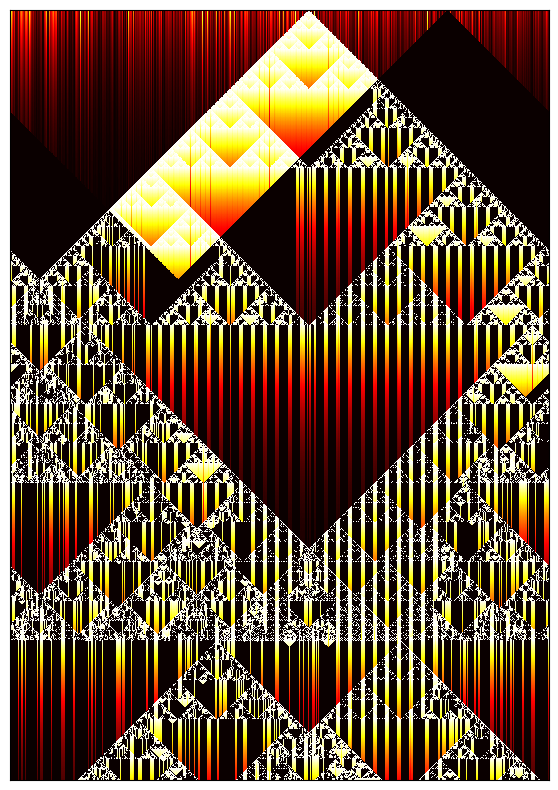

In [114]:
initial_row = sample[0:1750].to_numpy()

row_to_scale = initial_row.reshape(-1, 1)
scaler = MinMaxScaler()
scaled_row = scaler.fit_transform(row_to_scale)
normalized_row = scaled_row.flatten()

pattern = genomic_one_uniform_neighbor_max_min(
    normalized_row,
    num_rows=2500,
    background_decay=0.005,
    filename="one_uniform_neighbor_min_max_v2.png",
    cmap="hot",
    plot=True,
    save=False
)

In [ ]:
def genomic_one_uniform_neighbor_max_min_bw(
    initial_row, 
    num_rows, 
    sample_max, 
    sample_min,
    sample_mean,
    decay, 
    filename,
    cmap="gray",
    plot=False, 
    save=False,
    results_dir="results"
):
    """
    1D cellular automaton creating a matrix where each subsequent row is derived from the previous row applying 
    the exactly 1 neighbor is 1 rule. 

    Args:
        initial_row (binary list or np.array): first row of the matrix, specified by user
        num_rows (int): number of itterations to run (rows to derive and add to matrix)
        sample_max (float64): maximum value in intial row
        decay (int): for scaling color saturation
        cmap (str): Color map name (default = "twilight_shifted")

    Returns:
        np.array: resulting plot of generated pattern of unique shaded pyraminds 
    """

    initial_row = np.array(initial_row)
    matrix = [initial_row]

    for row in range(num_rows):
        current_row = matrix[-1]
        next_row = []
        for square in range(len(current_row)):
            
            left = current_row[square-1] if square > 0 else 0.5
            right = current_row[square+1] if square < len(current_row)-1 else 0.5
            center= current_row[square]
            
            if left == sample_min and center == sample_max:
                next_square = 0.25

            elif left == sample_max and center == sample_min:
                next_square = 0.75

            elif center == sample_max and right == sample_min:
                next_square = 0.25

            elif center == sample_min and right == sample_max:
                next_square = 0.75
                
            elif left == sample_max and right == sample_min:
                next_square = 0.5

            elif left == sample_min and right == sample_max:
                next_square = 0.5
                
            # apply XOR rule, exactly one neighbor is 1 for max value
            elif (left == sample_max) ^ (right == sample_max):
                next_square = sample_max

            # apply XOR rule, exactly one neighbor is 1 for min value
            elif (left == sample_min) ^ (right == sample_min):
                next_square = sample_min

            else:
                next_square = initial_row[square]

            next_row.append(next_square)
            
        matrix.append(next_row)

    matrix = np.array(matrix)

    if plot:
        fig, ax = plt.subplots(figsize=(6,6))
        ax.imshow(matrix, cmap=cmap, interpolation='nearest')
        ax.set_xticks([])
        ax.set_yticks([])

        if save:
            os.makedirs(results_dir, exist_ok=True)
            if filename is None:
                filename = "genomic_visualization.png"
            filepath = os.path.join(results_dir, filename)
            fig.savefig(filepath, dpi=300, bbox_inches="tight")

    return matrix

In [ ]:
initial_row = sample[0: 2000].to_numpy()
row_to_scale = initial_row.reshape(-1, 1)
scaled_row = [MinMaxScaler().fit_transform(row_to_scale)][0]
normalized_row = scaled_row.flatten()
sample_max = np.max(normalized_row)
sample_min = np.min(normalized_row)
sample_mean = np.mean(normalized_row)
size = len(normalized_row) 
decay = size/2

one_uniform_neighbor_min_max_bw_v1 = genomic_one_uniform_neighbor_max_min_bw(
    normalized_row, 
    num_rows=3500, 
    sample_max=sample_max,
    sample_min=sample_min,
    sample_mean=sample_mean,
    decay=decay, 
    filename="one_uniform_neighbor_min_max_bw_v1.png",
    cmap="hot",
    plot=True,
    save=False,
    results_dir="results"
)